Solution:
x1 = 5.0000
x2 = 3.0000
x3 = -2.0000


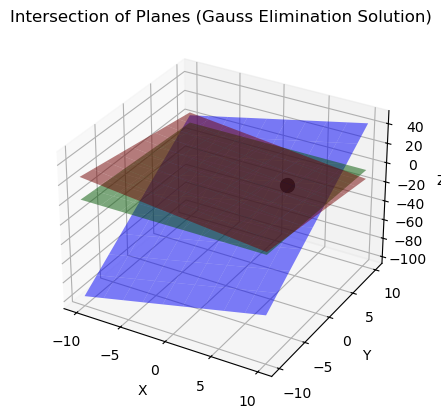

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Coefficients and constants
A = np.array([[1, 1, 1],
              [0, 2, 5],
              [2, 5, -1]], dtype=float)
b = np.array([6, -4, 27], dtype=float)

n = len(b)

# --- Gauss Elimination (Forward Elimination) ---
for i in range(n):
    # Pivot
    max_row = np.argmax(abs(A[i:, i])) + i
    A[[i, max_row]] = A[[max_row, i]]
    b[[i, max_row]] = b[[max_row, i]]

    for j in range(i+1, n):
        factor = A[j][i] / A[i][i]
        A[j] = A[j] - factor * A[i]
        b[j] = b[j] - factor * b[i]

# --- Back Substitution ---
x = np.zeros(n)
for i in range(n-1, -1, -1):
    x[i] = (b[i] - np.dot(A[i][i+1:], x[i+1:])) / A[i][i]

print("Solution:")
for i in range(n):
    print(f"x{i+1} = {x[i]:.4f}")

# --- Visualization (3D) ---
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Create meshgrid
x_vals = np.linspace(-10, 10, 10)
y_vals = np.linspace(-10, 10, 10)
X, Y = np.meshgrid(x_vals, y_vals)

# Plane equations from original system
Z1 = 6 - X - Y                    # From x + y + z = 6
Z2 = (-4 - 2*Y) / 5               # From 2y + 5z = -4
Z3 = (27 - 2*X - 5*Y) / -1        # From 2x + 5y - z = 27

# Plot the planes
ax.plot_surface(X, Y, Z1, alpha=0.5, color='red', label='Plane 1')
ax.plot_surface(X, Y, Z2, alpha=0.5, color='green', label='Plane 2')
ax.plot_surface(X, Y, Z3, alpha=0.5, color='blue', label='Plane 3')

# Mark the solution point
ax.scatter(x[0], x[1], x[2], color='black', s=100, label='Solution')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title("Intersection of Planes (Gauss Elimination Solution)")

plt.show()
